In [45]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch
from utils import *

# USE BATCH SIZE=1 TO USE OUR EVALUATION FUNCTIONS

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
triplets_original = [train_original[i]['triplets'] for i in range(len(train_original))]

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


In [40]:
# load the vae
from utils import load_model, get_pred_and_gt, verb_accuracy, handle_verbs_out, to_triplets
from evaluation_utils import find_checkpoint

model_path_vae = find_checkpoint('experiments/vae_objs_head/', 7819)
graph_type = 'gat'
print(model_path_vae)
vae = load_model('vae', model_path_vae, separate=True, output_dim=256, graph_type=graph_type)

experiments/vae_objs_head/VAE1000_objHead_gat_sep=True_fromae=False_od=256_kld=mean_b=1.0_drop=0.2_lr=0.0001_fl=False_eps=1.0_1726587819/checkpoints/last.ckpt
Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


# VAE posterior sampling given an input on trainset

In [46]:
verbs_output_vae, verbs_gt_vae, objs_output_vae, objs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)

In [47]:
rels_output_vae[0].size()

torch.Size([1, 391, 14])

In [185]:
def to_triplets2(verbs_gt, objs_gt, rels_gt, verbs_out, objs_out, rels_out):
    ''' function to build the triplets from models output'''
    triplets_gt = []
    triplets_pred = []
    
    for i in range(len(verbs_gt)):
        # BUILD THE GT TRIPLETS
        rel_gt = rels_gt[i].squeeze()
        obj_rels_gt = torch.nonzero(rel_gt[:,:13])

        verb = verbs_gt[i].repeat(len(obj_rels_gt),1)
        triplets_gt.append(torch.cat((verb,obj_rels_gt), dim=1))

        # BUILD THE PREDICTED TRIPLETS
        # Apply softmax to objs_out to get predicted objects
        obj_probs = torch.softmax(objs_out[i], dim=-1)
        obj_pred = (obj_probs > 0.5).float()  # Filter objects with probability > 0.5
        obj_indices = torch.nonzero(obj_pred).squeeze()  # Get indices of predicted objects

        rels_pred = []
        if len(obj_indices) == 0:
            obj_indices = torch.argmax(objs_out[i]).unsqueeze(0)
        
        # get predicted verb
        verb_pred = torch.argmax(verbs_out[i]).unsqueeze(0).unsqueeze(0).repeat(len(obj_indices),1)
            
        for obj_index in obj_indices:
            rels_out_temp = rels_out[i].squeeze()
            rels_pred.append(torch.argmax(rels_out_temp[obj_index,:13]))

        objs_pred = obj_indices.unsqueeze(1)
        rels_pred = torch.vstack(rels_pred)
        

        triplets_pred.append(torch.cat((verb_pred, objs_pred, rels_pred), dim=1))
    return triplets_gt, triplets_pred

In [169]:
a = torch.tensor(2)
a.size()

torch.Size([])

In [186]:
gt_vae2, pred_vae2 = to_triplets2(verbs_gt_vae, objs_gt_vae, rels_gt_vae, verbs_output_vae, objs_output_vae, rels_output_vae)
# print(obj_indices.size())
# print(obj_indices)

tensor([21], device='cuda:0')
tensor([220], device='cuda:0')
tensor([279], device='cuda:0')
tensor([171], device='cuda:0')
tensor([198], device='cuda:0')
tensor([263], device='cuda:0')
tensor([263], device='cuda:0')
tensor([84], device='cuda:0')
tensor([21], device='cuda:0')
tensor([84], device='cuda:0')
tensor([291], device='cuda:0')
tensor([193], device='cuda:0')
tensor([301], device='cuda:0')
tensor([84], device='cuda:0')
tensor([30], device='cuda:0')
tensor([263], device='cuda:0')
tensor([100], device='cuda:0')
tensor([263], device='cuda:0')
tensor([263], device='cuda:0')
tensor([263], device='cuda:0')
tensor([21], device='cuda:0')
tensor([263], device='cuda:0')
tensor([229], device='cuda:0')
tensor([96], device='cuda:0')
tensor([171], device='cuda:0')
tensor([263], device='cuda:0')
tensor([171], device='cuda:0')
tensor([17], device='cuda:0')
tensor([117], device='cuda:0')
tensor([263], device='cuda:0')
tensor([149], device='cuda:0')
tensor([21], device='cuda:0')
tensor([171], devi

In [107]:
obj_indices

tensor([[162,   0,   1],
        [162, 212,   1]], device='cuda:0')

In [48]:
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
gt_vae, pred_vae = to_triplets(verbs_gt_vae, rels_gt_vae, verbs_output_vae, rels_output_vae)
# gt_vae2, pred_vae2 = to_triplets2(verbs_gt_vae, objs_gt_vae, rels_gt_vae, verbs_output_vae, objs_output_vae, rels_output_vae)

98.666 %


In [67]:
pred_vae[0]

tensor([[162, 171,   3],
        [162, 212,   1]], device='cuda:0')

In [38]:
pred_vae[0]

tensor([[162, 171,   3],
        [162, 212,   1]], device='cuda:0')

In [5]:
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

2.826 %


In [6]:
correct_vae = 0
error_indices_vae = []
for i in range(len(gt_vae)):
    if gt_vae[i].size(0) == pred_vae[i].size(0):
        gt_vae[i] = gt_vae[i].to(device)    # why to device?
        if torch.all((gt_vae[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(gt_vae)):.2f} %")

62.14 %


# VAE posterior sampling given an input on validation set

In [7]:
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, val_loader)

In [8]:
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
gt_vae, pred_vae = to_triplets(verbs_gt_vae, rels_gt_vae, verbs_output_vae, rels_output_vae)

9.236 %


In [9]:
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

26.952 %


In [10]:
correct_vae = 0
error_indices_vae = []
for i in range(len(gt_vae)):
    if gt_vae[i].size(0) == pred_vae[i].size(0):
        gt_vae[i] = gt_vae[i].to(device)    # why to device?
        if torch.all((gt_vae[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(gt_vae)):.2f} %")

0.50 %


# Prior Sampling (From a Random Latent Space Vector)

In [11]:
num_samples = 10000
codes_dim = 256

decoder = vae.decoder.to(device)
decoded_samples = decoder(torch.randn(num_samples, codes_dim).to(device))
decoded_triplets = get_pred_triplets(decoded_samples[0], decoded_samples[1])

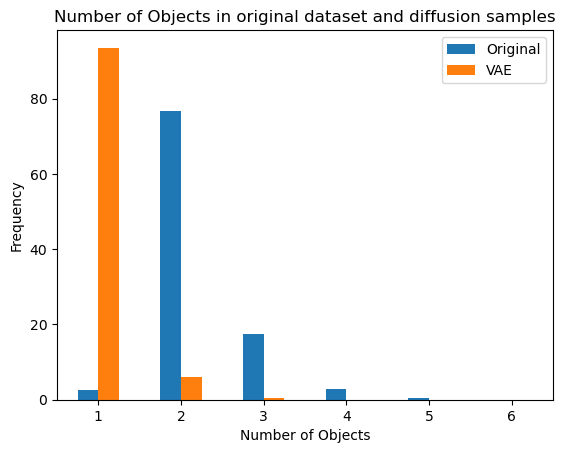

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training and validation sample
num_objects_train = [triplets_original[i].size(0) for i in range(len(triplets_original))]
num_objects_diff = [decoded_triplets[i].size(0) for i in range(len(decoded_triplets))]

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Original')
objects_diff_pd = pd.Series(num_objects_diff, name='VAE')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_train_count = objects_train_count*100/objects_train_count.sum()
objects_diff_count = objects_diff_pd.value_counts().sort_index()
objects_diff_count = objects_diff_count*100/objects_diff_count.sum()

# Combine both Series into a DataFrame
objects_count_df = pd.DataFrame({'Original': objects_train_count, 'VAE': objects_diff_count}).fillna(0)

objects_count_df.plot.bar()
plt.xticks(rotation=0)
plt.title('Number of Objects in original dataset and diffusion samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()


In [13]:
# Initialize counters
count_0 = 0
count_1 = 0
count_2 = 0
count_3 = 0

# Loop through triplets_diffusion once
for el in decoded_triplets:
    triplet_size = el.size(0)
    if triplet_size == 0:
        count_0 += 1
    elif triplet_size == 1:
        count_1 += 1
    elif triplet_size == 2:
        count_2 += 1
    elif triplet_size == 3:
        count_3 += 1

# Total number of elements
total = len(decoded_triplets)

# Print the percentages
print(f'{(count_0 * 100 / total):.2f} % of graphs result in empty triplets')
print(f'{(count_1 * 100 / total):.2f} % of graphs have 1 triplet')
print(f'{(count_2 * 100 / total):.2f} % of graphs have 2 triplets')
print(f'{(count_3 * 100 / total):.2f} % of graphs have 3 triplets')

0.00 % of graphs result in empty triplets
93.51 % of graphs have 1 triplet
5.95 % of graphs have 2 triplets
0.51 % of graphs have 3 triplets


In [14]:
def compare_statistics2(list1, list2, names_list, list1_name:str='train', list2_name:str='validation',  stat:str = 'verb', other=False, save=False):
    ''' function used to compare train and validation statistics or train and samples from diffusion models/VAE''' 
    import matplotlib.pyplot as plt
    from collections import Counter
    import pandas as pd
    import numpy as np

    # Create Counters for both lists
    c1 = Counter(list1)
    c2 = Counter(list2)

    # Extract the top 10 elements from each list
    top10_1 = c1.most_common(10)
    top10_2 = c2.most_common(10)

    if other:
        # Calculate the sum of all other
        other_count_1 = sum(c1.values()) - sum(count for _,count in top10_1)
        other_count_2 = sum(c2.values()) - sum(count for _,count in top10_2)

        top10_1.append(('Other', other_count_1))
        top10_2.append(('Other', other_count_2))

    # Create a set of unique elements from both top 10 lists
    unique_elements = set([el[0] for el in top10_1] + [el[0] for el in top10_2])

    # Get the total counts for calculating percentages
    total_count_1 = sum(c1.values())
    total_count_2 = sum(c2.values())

    # Create a dictionary to hold the percentage data for each element
    data1 = {el: c1[el] / total_count_1 * 100 for el in unique_elements}
    data2 = {el: c2[el] / total_count_2 * 100 for el in unique_elements}

    # Prepare the data for plotting
    names = [names_list[el] if el != 'Other' else 'Other' for el in unique_elements]
    percentages1 = [data1[el] for el in unique_elements]
    percentages2 = [data2[el] for el in unique_elements]

    # Sort the names and percentages by the first dataset (optional)
    sorted_indices = np.argsort(percentages1)[::-1]
    names = np.array(names)[sorted_indices]
    percentages1 = np.array(percentages1)[sorted_indices]
    percentages2 = np.array(percentages2)[sorted_indices]

    # Plot the data in a single bar chart with two bars per category
    fig, ax = plt.subplots(figsize=(8, 6))
    width = 0.35  # the width of the bars

    # Create the positions for the bars
    indices = np.arange(len(names))

    # Plotting both sets of data side by side
    ax.bar(indices - width/2, percentages1, width, label=list1_name, color='cornflowerblue')
    ax.bar(indices + width/2, percentages2, width, label=list2_name, color='rosybrown')

    # Add some labels and titles
    ax.set_xlabel(f'{stat}')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Comparison of Top 10 {stat} Frequencies')
    ax.set_xticks(indices)
    ax.set_xticklabels(names, rotation=45, ha='right')

    # Add a legend
    ax.legend()

    # Adjust layout and show plot
    plt.tight_layout()

    if save: plt.savefig(f'perc_{stat}_{other}.jpg', format='jpg', dpi=500)
    plt.show()

    return c1, c2


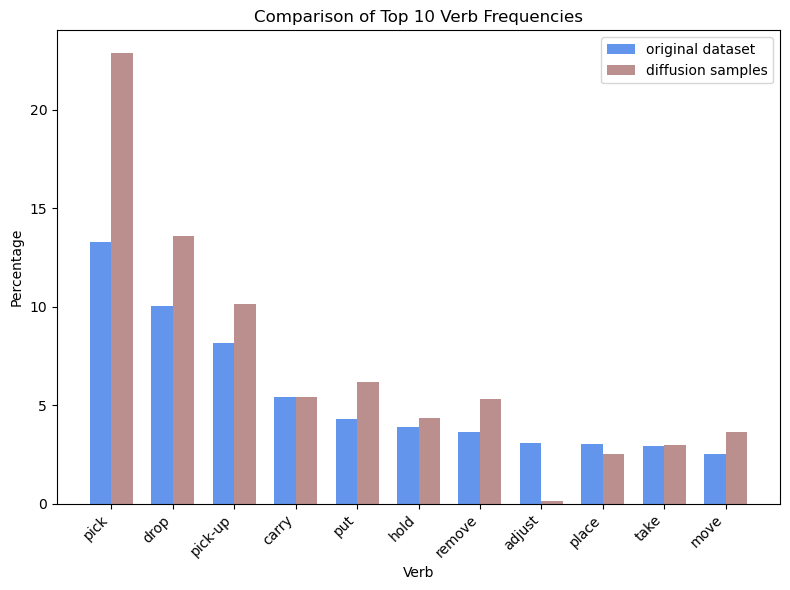

(Counter({89: 1128,
          36: 850,
          91: 691,
          12: 458,
          108: 365,
          58: 328,
          115: 310,
          1: 262,
          92: 255,
          162: 247,
          79: 212,
          82: 172,
          98: 142,
          174: 138,
          26: 128,
          86: 111,
          103: 101,
          104: 99,
          102: 88,
          177: 80,
          18: 74,
          29: 74,
          69: 70,
          30: 69,
          193: 69,
          119: 68,
          21: 68,
          120: 63,
          173: 63,
          124: 59,
          85: 58,
          178: 58,
          49: 55,
          65: 55,
          181: 53,
          112: 47,
          4: 47,
          164: 45,
          60: 40,
          132: 40,
          77: 39,
          154: 34,
          105: 33,
          122: 29,
          109: 28,
          10: 27,
          5: 27,
          84: 25,
          34: 24,
          126: 24,
          13: 24,
          95: 23,
          72: 20,
        

In [15]:
from evaluation_utils import compare_statistics
verbs_list_original = [triplet[0].item() for triplets in triplets_original for triplet in triplets]
verbs_list_vae = [triplet[0].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics2(verbs_list_original, verbs_list_vae, verbs, 'original dataset', 'diffusion samples', 'Verb')

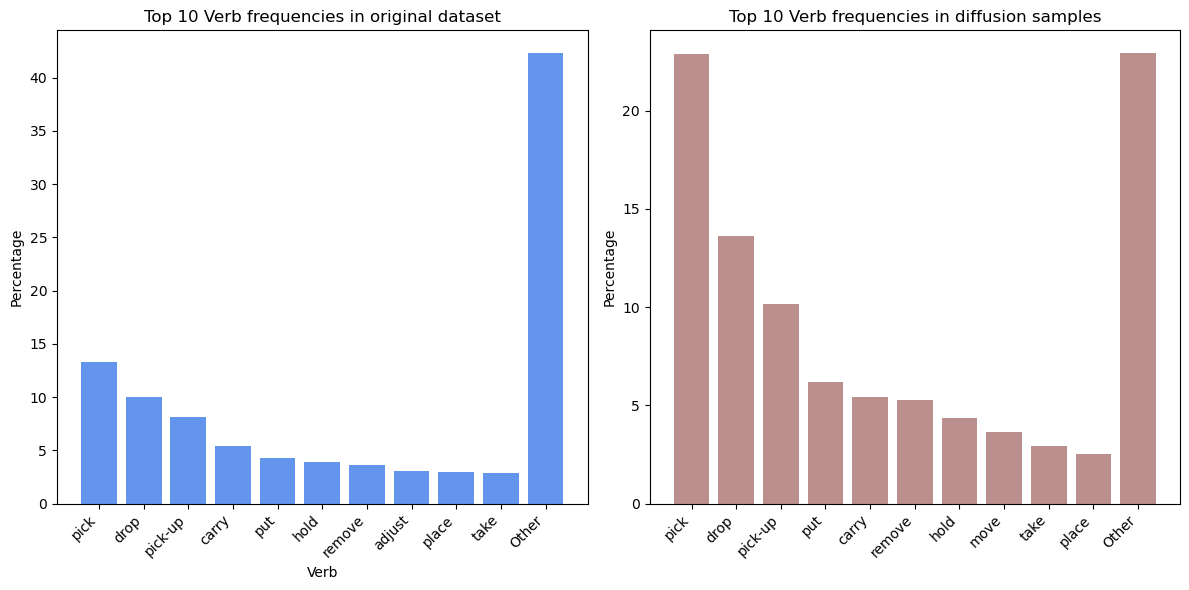

(Counter({89: 1128,
          36: 850,
          91: 691,
          12: 458,
          108: 365,
          58: 328,
          115: 310,
          1: 262,
          92: 255,
          162: 247,
          79: 212,
          82: 172,
          98: 142,
          174: 138,
          26: 128,
          86: 111,
          103: 101,
          104: 99,
          102: 88,
          177: 80,
          18: 74,
          29: 74,
          69: 70,
          30: 69,
          193: 69,
          119: 68,
          21: 68,
          120: 63,
          173: 63,
          124: 59,
          85: 58,
          178: 58,
          49: 55,
          65: 55,
          181: 53,
          112: 47,
          4: 47,
          164: 45,
          60: 40,
          132: 40,
          77: 39,
          154: 34,
          105: 33,
          122: 29,
          109: 28,
          10: 27,
          5: 27,
          84: 25,
          34: 24,
          126: 24,
          13: 24,
          95: 23,
          72: 20,
        

In [16]:
compare_statistics(verbs_list_original, verbs_list_vae, verbs, 'original dataset', 'diffusion samples', 'Verb', other=True)

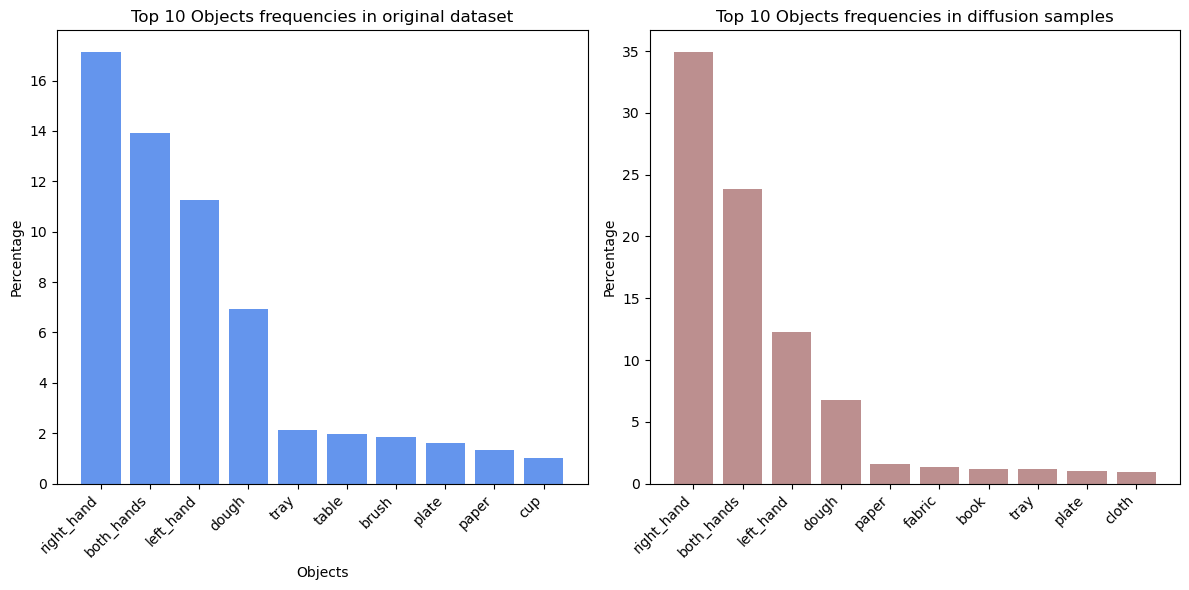

(Counter({263: 1454,
          21: 1181,
          171: 956,
          96: 587,
          354: 180,
          330: 167,
          33: 156,
          243: 138,
          220: 112,
          84: 87,
          110: 78,
          23: 77,
          67: 72,
          383: 65,
          335: 64,
          118: 62,
          18: 61,
          153: 61,
          240: 60,
          73: 60,
          149: 57,
          301: 54,
          17: 54,
          34: 53,
          207: 52,
          316: 51,
          291: 50,
          251: 49,
          15: 47,
          290: 46,
          4: 45,
          388: 45,
          376: 45,
          182: 43,
          43: 43,
          86: 41,
          380: 41,
          117: 39,
          174: 38,
          198: 36,
          50: 36,
          215: 35,
          312: 34,
          6: 33,
          22: 33,
          288: 31,
          191: 30,
          46: 30,
          317: 29,
          289: 27,
          219: 25,
          357: 25,
          164: 25,
  

In [17]:
objs_list_original = [triplet[1].item() for triplets in triplets_original for triplet in triplets]
objs_list_vae = [triplet[1].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics(objs_list_original, objs_list_vae, objs, 'original dataset', 'diffusion samples', 'Objects', other=False)

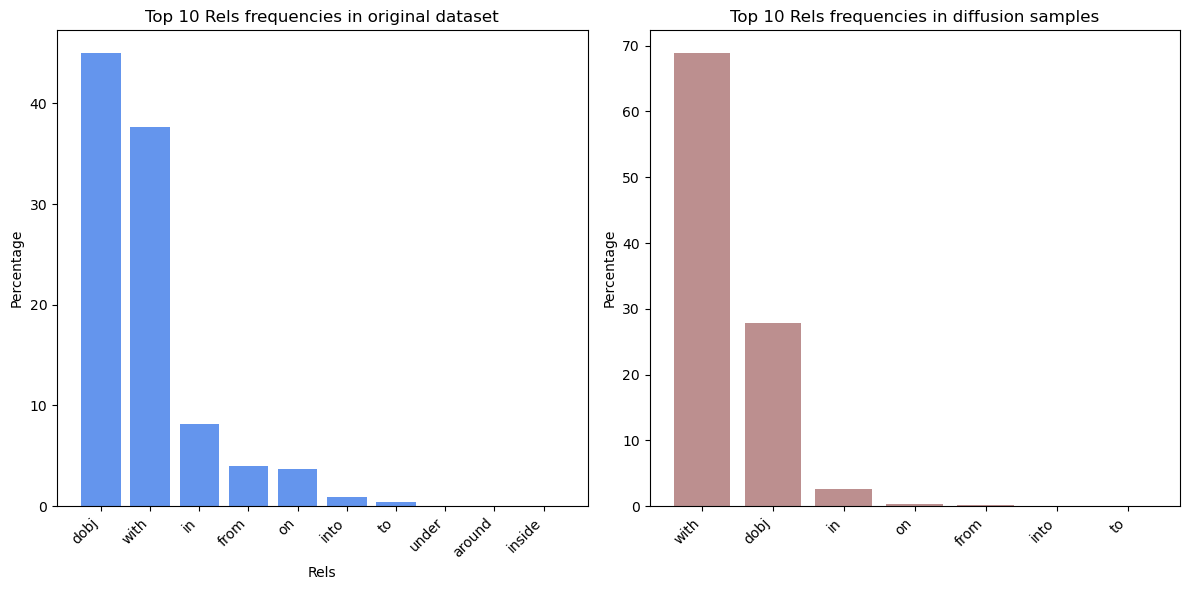

(Counter({1: 3819,
          12: 3196,
          3: 694,
          2: 342,
          6: 312,
          5: 80,
          9: 31,
          11: 3,
          0: 3,
          4: 2,
          8: 2,
          10: 1}),
 Counter({12: 7375, 1: 2982, 3: 280, 6: 34, 2: 26, 5: 8, 9: 1}))

In [18]:
rels_list_original = [triplet[2].item() for triplets in triplets_original for triplet in triplets]
rels_list_diffusion = [triplet[2].item() for triplets in decoded_triplets for triplet in triplets]

compare_statistics(rels_list_original, rels_list_diffusion, rels, 'original dataset', 'diffusion samples', 'Rels', other=False)

# t-SNE

In [15]:
import numpy as np
from sklearn.manifold import TSNE

# Step 1: Obtain Latent Representations from the VAE
vae.eval()  # Set VAE to evaluation mode
latent_vectors = []
verb_labels = []
object_labels = []
relationship_labels = []

with torch.no_grad():
    for data in train_loader:
        batch, v_gt, rel_gt = data
        objs = (rel_gt == 1).nonzero(as_tuple=False)
        objects = objs[objs[:, 2] != 13][:,1]
        # rels = objs[objs[:, 2]][:, 2]
        rels = objs[objs[:, 2] != 13][:, 2]
        batch = batch.to(device)
        z = vae.encode(batch)
        latent_vectors.append(z.cpu().numpy())
        verb_labels.append(v_gt.cpu().numpy())
        object_labels.extend([el.cpu().numpy().item() for el in objects])
        relationship_labels.extend([el.cpu().numpy().item() for el in rels])

# Concatenate all latent vectors and labels into single arrays
latent_vectors = np.concatenate(latent_vectors, axis=0)
verb_labels = np.concatenate(verb_labels, axis=0)

# Step 2: Apply t-SNE to the Latent Vectors
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

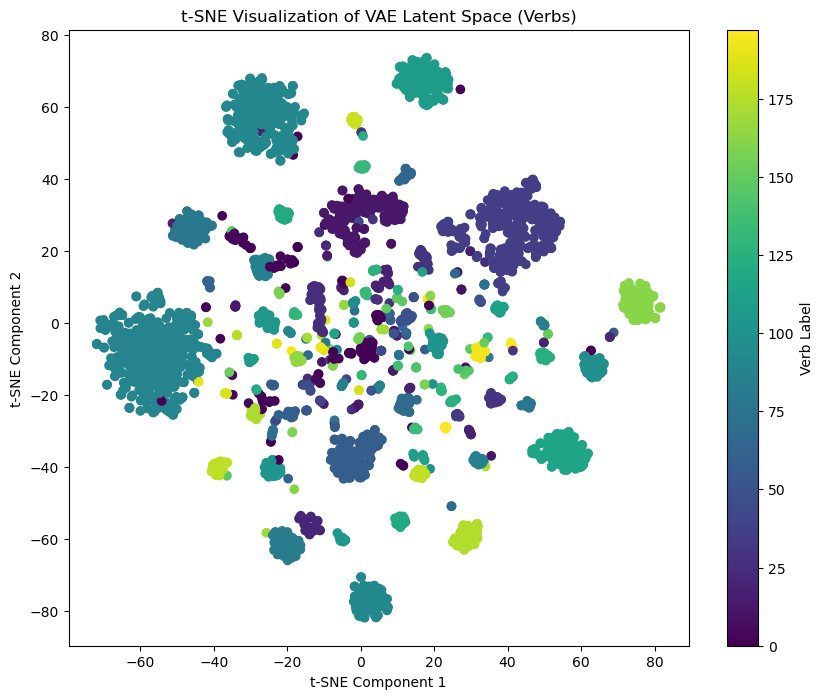

In [16]:
# Plot the t-SNE Visualization with verb labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=verb_labels, cmap='viridis')
plt.colorbar(scatter, label='Verb Label')
plt.title("t-SNE Visualization of VAE Latent Space (Verbs)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

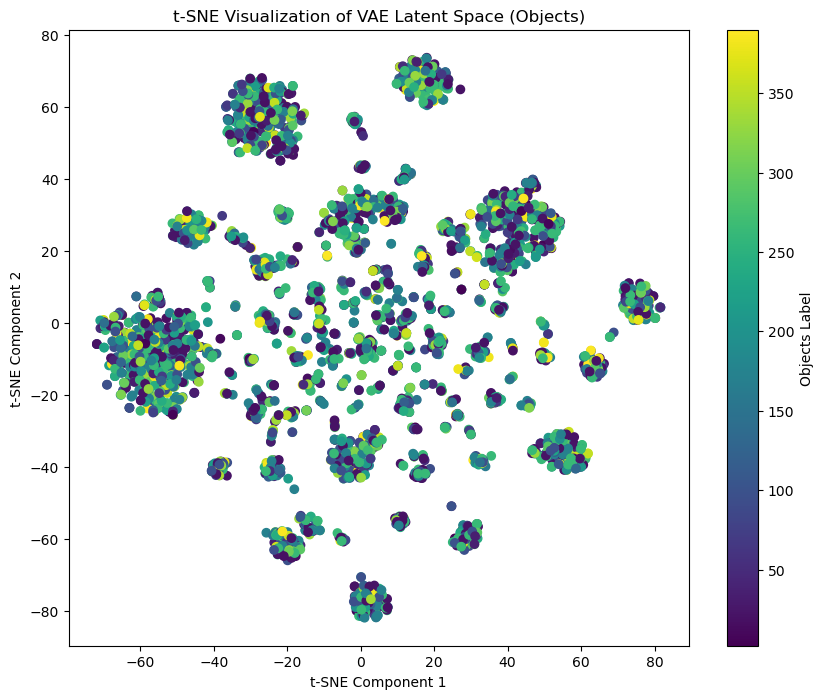

In [17]:
# Plot the t-SNE Visualization with object labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=object_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Objects Label')
plt.title("t-SNE Visualization of VAE Latent Space (Objects)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

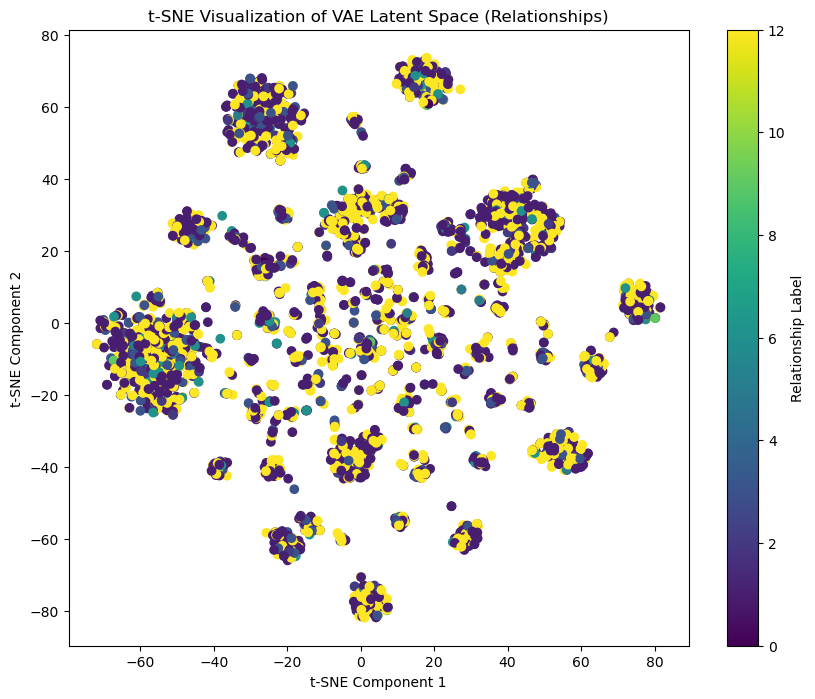

In [18]:
# Plot the t-SNE Visualization with relationship labels
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=relationship_labels[:len(train_dataset)], cmap='viridis')
plt.colorbar(scatter, label='Relationship Label')
plt.title("t-SNE Visualization of VAE Latent Space (Relationships)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()